<a href="https://colab.research.google.com/github/Aryamaan777/Finance/blob/TradingStrategies/TradingStrategies/Live_Paper_Trading_Simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

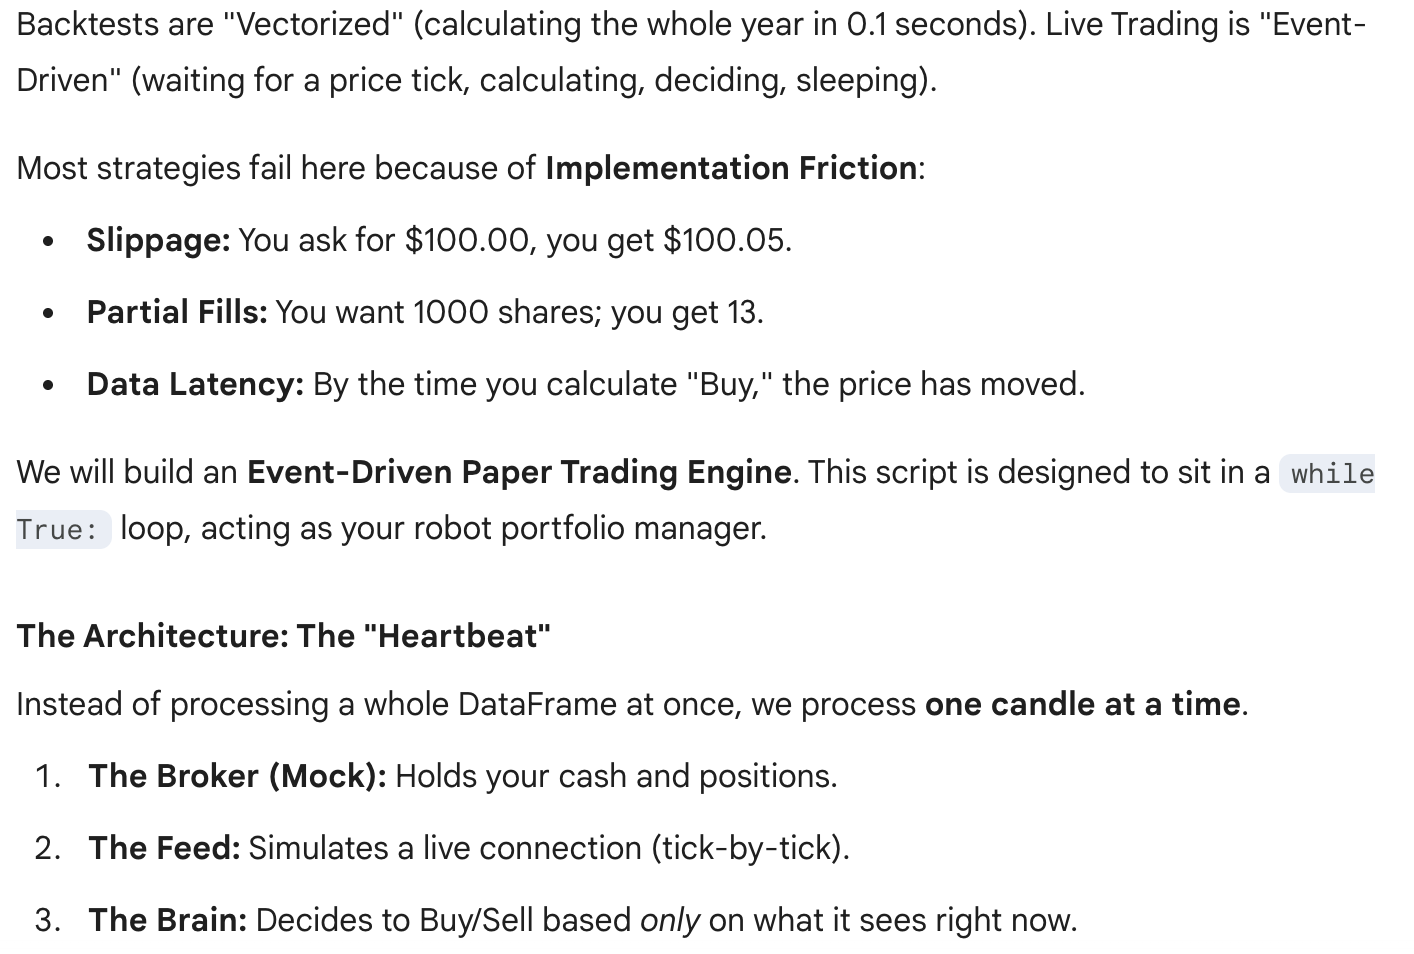

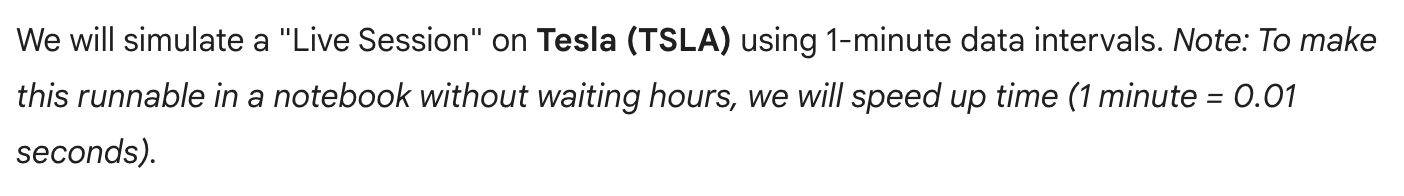

In [6]:
import pandas as pd
import numpy as np
import yfinance as yf
import time
from datetime import datetime
import matplotlib.pyplot as plt

In [2]:
# --- 1. THE MOCK BROKER (The "Exchange") ---
class MockBroker:
    def __init__(self, initial_capital=100000, transaction_cost=0.001):
        self.cash = initial_capital
        self.positions = {} # {ticker: shares}
        self.transaction_cost = transaction_cost # 0.1% fee/slippage
        self.trade_log = []
        self.equity_curve = []

    def get_price(self, ticker, current_market_data):
        # In real life, this calls API. Here, it grabs the current row's close.
        return current_market_data['Close']

    def submit_order(self, ticker, amount_cash, side, price, timestamp):
        """
        Executes an order immediately (Market Order logic)
        """
        # Calculate Slippage/Fee
        cost = amount_cash * self.transaction_cost

        if side == 'BUY':
            if self.cash >= amount_cash:
                # Execute
                shares = (amount_cash - cost) / price
                self.cash -= amount_cash
                self.positions[ticker] = self.positions.get(ticker, 0) + shares

                print(f"🟢 [BUY]  {timestamp} | {ticker} | Price: ${price:.2f} | Shares: {shares:.2f}")
                self.trade_log.append({'Date': timestamp, 'Type': 'BUY', 'Price': price, 'Shares': shares, 'Value': amount_cash})
                return True
            else:
                print(f"❌ [FAIL] Not enough cash to buy {ticker}")
                return False

        elif side == 'SELL':
            # Sell EVERYTHING (simple logic)
            if self.positions.get(ticker, 0) > 0:
                shares = self.positions[ticker]
                gross_proceeds = shares * price
                net_proceeds = gross_proceeds * (1 - self.transaction_cost)

                self.cash += net_proceeds
                self.positions[ticker] = 0

                print(f"🔴 [SELL] {timestamp} | {ticker} | Price: ${price:.2f} | PnL: See Log")
                self.trade_log.append({'Date': timestamp, 'Type': 'SELL', 'Price': price, 'Shares': shares, 'Value': net_proceeds})
                return True
            else:
                return False

    def mark_to_market(self, ticker, price, timestamp):
        # Calculate Total Account Value
        pos_val = self.positions.get(ticker, 0) * price
        total_equity = self.cash + pos_val
        self.equity_curve.append({'Date': timestamp, 'Equity': total_equity})
        return total_equity

In [3]:
# --- 2. THE STRATEGY BOT (The "Brain") ---
class LiveStrategy:
    def __init__(self, fast_ma=9, slow_ma=21):
        self.fast_ma = fast_ma
        self.slow_ma = slow_ma
        self.prices = [] # Internal memory to calculate MA on the fly

    def on_tick(self, price):
        """
        Ingests a new price tick, updates indicators, returns Signal.
        """
        self.prices.append(price)

        # Need enough data to calculate MAs
        if len(self.prices) < self.slow_ma:
            return "HOLD"

        # Calculate Indicators (Simple Moving Average)
        # In a real bot, we would use talib or pandas rolling on the buffer
        ma_fast = np.mean(self.prices[-self.fast_ma:])
        ma_slow = np.mean(self.prices[-self.slow_ma:])

        # Crossover Logic
        if ma_fast > ma_slow:
            return "BUY"
        elif ma_fast < ma_slow:
            return "SELL"
        else:
            return "HOLD"

print("✅ Broker and Strategy Bot initialized.")

✅ Broker and Strategy Bot initialized.


In [4]:
# --- CONFIGURATION ---
ticker = 'TSLA'
print(f"📥 Downloading 'Live' Data for {ticker}...")

# Fetch intraday data to simulate "live" feed
# Note: yfinance 1m/5m data is limited to last 60 days
live_feed = yf.download(ticker, period='5d', interval='5m', progress=False)

# Initialize
broker = MockBroker(initial_capital=100000)
bot = LiveStrategy(fast_ma=12, slow_ma=26) # MACD-ish settings

print(f"🤖 STARTING LIVE SIMULATION ({len(live_feed)} ticks)...")
print("-" * 60)

# --- THE EVENT LOOP ---
# This simulates the passage of time
for i in range(len(live_feed)):

    # 1. "Wait" for the next candle (Simulated)
    # In real life: time.sleep(60)
    current_row = live_feed.iloc[i]
    if isinstance(current_row, pd.Series): # Handle multi-index quirk
         # For recent yfinance versions, simple access works.
         # If MultiIndex (Price, Ticker), we need .iloc
         pass

    timestamp = live_feed.index[i]
    # Handle yfinance recent formatting (sometimes returns tuple columns)
    try:
        current_price = float(current_row['Close'].iloc[0]) if isinstance(current_row['Close'], pd.Series) else float(current_row['Close'])
    except:
        current_price = float(current_row['Close'])

    # 2. Feed Brain
    signal = bot.on_tick(current_price)

    # 3. Execution Logic (State Machine)
    # Only buy if we have Cash
    # Only sell if we have Shares
    has_position = broker.positions.get(ticker, 0) > 0

    if signal == "BUY" and not has_position:
        # Commit 95% of cash (leave buffer)
        amount_to_invest = broker.cash * 0.95
        broker.submit_order(ticker, amount_to_invest, 'BUY', current_price, timestamp)

    elif signal == "SELL" and has_position:
        broker.submit_order(ticker, 0, 'SELL', current_price, timestamp)

    # 4. Reporting (Mark to Market)
    current_equity = broker.mark_to_market(ticker, current_price, timestamp)

    # Optional: Print status every 50 ticks to show it's alive
    if i % 50 == 0:
        print(f"⏳ {timestamp} | Equity: ${current_equity:,.0f} | Signal: {signal}")

print("-" * 60)
print("🏁 SIMULATION COMPLETE.")

📥 Downloading 'Live' Data for TSLA...


/tmp/ipython-input-651085879.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  live_feed = yf.download(ticker, period='5d', interval='5m', progress=False)


🤖 STARTING LIVE SIMULATION (390 ticks)...
------------------------------------------------------------
⏳ 2026-01-12 14:30:00+00:00 | Equity: $100,000 | Signal: HOLD
🟢 [BUY]  2026-01-12 16:35:00+00:00 | TSLA | Price: $450.83 | Shares: 210.51
🔴 [SELL] 2026-01-12 18:35:00+00:00 | TSLA | Price: $451.10 | PnL: See Log
⏳ 2026-01-12 18:40:00+00:00 | Equity: $99,867 | Signal: SELL
🟢 [BUY]  2026-01-13 16:15:00+00:00 | TSLA | Price: $450.73 | Shares: 210.28
⏳ 2026-01-13 16:20:00+00:00 | Equity: $99,648 | Signal: BUY
🔴 [SELL] 2026-01-13 17:35:00+00:00 | TSLA | Price: $448.43 | PnL: See Log
🟢 [BUY]  2026-01-13 20:25:00+00:00 | TSLA | Price: $446.23 | Shares: 210.97
⏳ 2026-01-13 20:30:00+00:00 | Equity: $99,106 | Signal: BUY
🔴 [SELL] 2026-01-14 14:35:00+00:00 | TSLA | Price: $440.63 | PnL: See Log
⏳ 2026-01-14 18:10:00+00:00 | Equity: $97,825 | Signal: SELL
🟢 [BUY]  2026-01-14 18:40:00+00:00 | TSLA | Price: $436.08 | Shares: 212.90
⏳ 2026-01-15 15:50:00+00:00 | Equity: $99,067 | Signal: BUY
🔴 [SELL


📊 SESSION REPORT: TSLA
Final Equity: $95,708.27
Return:       -4.29%
Trades Executed: 16


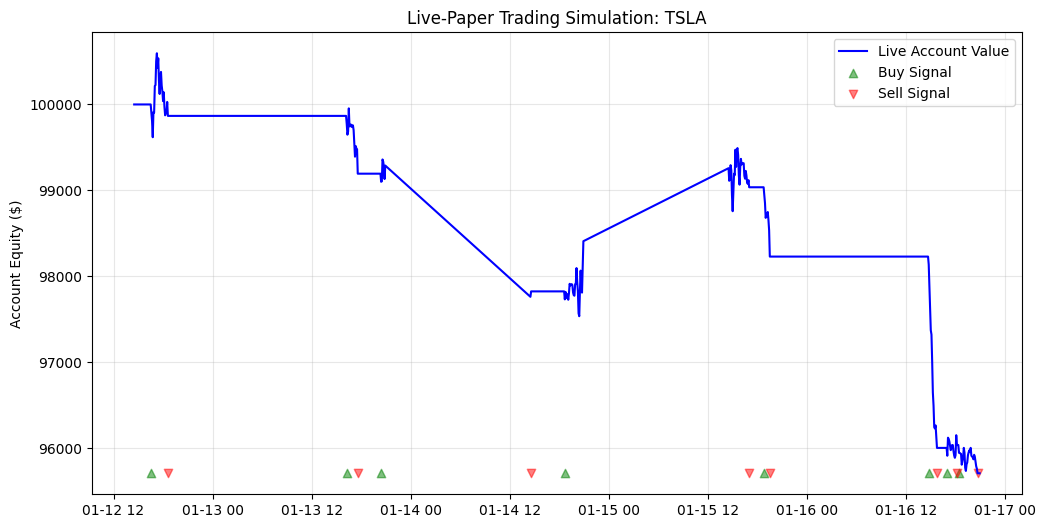

In [7]:
# --- AUDIT THE LIVE SESSION ---
equity_df = pd.DataFrame(broker.equity_curve)
equity_df.set_index('Date', inplace=True)

trades_df = pd.DataFrame(broker.trade_log)

# Calculate metrics
if not equity_df.empty:
    initial = 100000
    final = equity_df['Equity'].iloc[-1]
    ret = (final / initial) - 1

    print(f"\n📊 SESSION REPORT: {ticker}")
    print(f"Final Equity: ${final:,.2f}")
    print(f"Return:       {ret*100:.2f}%")
    print(f"Trades Executed: {len(trades_df)}")

    # Plotting
    plt.figure(figsize=(12, 6))
    plt.plot(equity_df.index, equity_df['Equity'], label='Live Account Value', color='blue')

    # Overlay Trades
    if not trades_df.empty:
        buys = trades_df[trades_df['Type'] == 'BUY']
        sells = trades_df[trades_df['Type'] == 'SELL']
        plt.scatter(buys['Date'], [final]*len(buys), marker='^', color='green', label='Buy Signal', alpha=0.5)
        plt.scatter(sells['Date'], [final]*len(sells), marker='v', color='red', label='Sell Signal', alpha=0.5)

    plt.title(f"Live-Paper Trading Simulation: {ticker}")
    plt.ylabel("Account Equity ($)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("No data processed.")

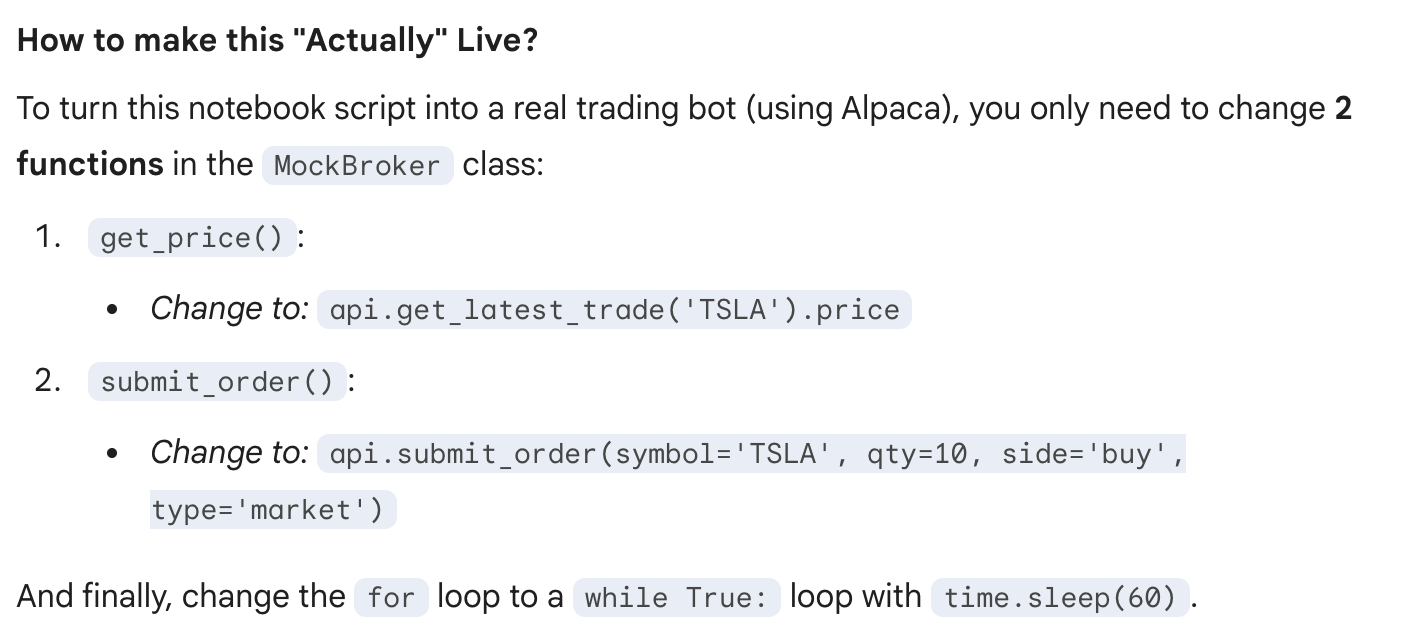